# Random Forest Regression

Random Forest Regression is a supervised machine learning algorithm
used to predict continuous numerical values.

Random Forest is an ensemble learning method.

Instead of using one Decision Tree, Random Forest creates many Decision
Trees and combines their predictions.

Basic idea:

Dataset
   ↓
Multiple Decision Trees
   ↓
Each Tree Makes a Prediction
   ↓
Average All Predictions
   ↓
Final Prediction

## Ensemble Learning

Ensemble Learning combines multiple machine learning models to create
a stronger overall model.

Instead of relying on one model:

Model 1
Model 2
Model 3
Model 4

Their predictions are combined to produce the final prediction.

Random Forest is an example of ensemble learning.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [11]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [13]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [14]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

Therefore:

total_bill + size
       ↓
Random Forest Regressor
       ↓
tip

In [15]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2
4       24.59     4

Target:
0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64


In [16]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2
4       24.59     4

Target:
0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)s

Training: (195, 2)
Testing: (49, 2)


## Creating the Random Forest

We will use:

RandomForestRegressor

The model will create multiple decision trees.

Each tree learns from a slightly different sample of the training
data.

The predictions from all trees are then averaged to produce the final
prediction.

In [18]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [19]:
model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [20]:
y_pred = model.predict(
    X_test
)

y_pred[:10]

array([3.648     , 1.7454    , 3.5785    , 4.2555    , 1.9236    ,
       3.35443333, 3.1381    , 1.647     , 2.3789    , 1.6917    ])

In [21]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,3.648000
1,2.00,1.745400
2,2.00,3.578500
3,5.16,4.255500
4,2.00,1.923600
5,2.00,3.354433
6,2.56,3.138100
7,2.52,1.647000
8,3.23,2.378900
9,3.00,1.691700


In [22]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.7367653061224487


In [23]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.8342787953514748


In [24]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.9133886332506415


In [25]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.3325616635080578


In [26]:
print("Random Forest Regression Performance")
print("-------------------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest Regression Performance
-------------------------------------
MAE : 0.7367653061224487
MSE : 0.8342787953514748
RMSE: 0.9133886332506415
R²  : 0.3325616635080578


## n_estimators

`n_estimators` represents the number of Decision Trees in the Random
Forest.

Example:

n_estimators = 10
→ 10 Decision Trees

n_estimators = 100
→ 100 Decision Trees

n_estimators = 500
→ 500 Decision Trees

Generally, increasing the number of trees can improve stability, but
it also increases computation time.

There is usually a point after which adding more trees provides little
additional benefit.

In [27]:
tree_counts = [10, 25, 50, 100, 200, 300]

results = []

for n in tree_counts:

    forest = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    forest.fit(
        X_train,
        y_train
    )

    predictions = forest.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "n_estimators": n,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,n_estimators,RMSE,R2
0,10,0.876627,0.385206
1,25,0.908085,0.340290
2,50,0.895638,0.358251
3,100,0.913389,0.332562
4,200,0.908578,0.339573
5,300,0.899278,0.353025


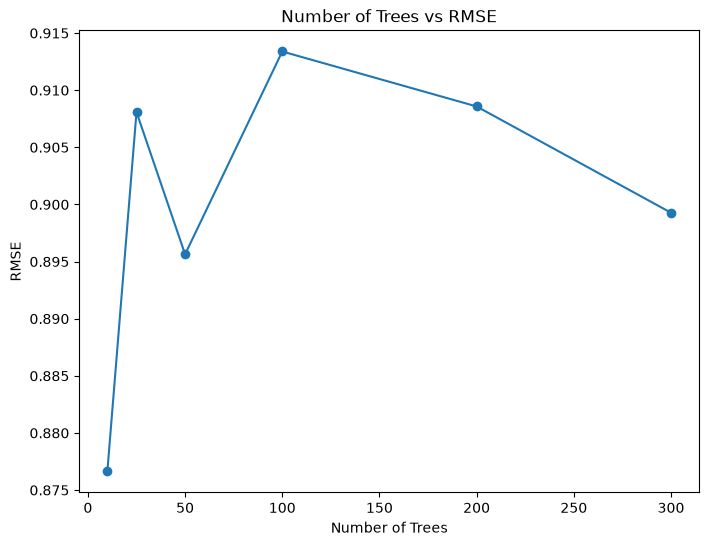

In [28]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["n_estimators"],
    results_df["RMSE"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("Number of Trees vs RMSE")

plt.show()

## Important Random Forest Hyperparameters

### n_estimators

Number of decision trees.

### max_depth

Maximum depth of each decision tree.

### min_samples_split

Minimum number of samples required to split a node.

### min_samples_leaf

Minimum number of samples required in a leaf.

### max_features

Number of features considered when searching for a split.

### bootstrap

Whether bootstrap samples are used to train the individual trees.

These parameters control the complexity and performance of the
Random Forest.

In [29]:
forest_depth = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

forest_depth.fit(
    X_train,
    y_train
)

depth_pred = forest_depth.predict(
    X_test
)

print(
    "R²:",
    r2_score(y_test, depth_pred)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            depth_pred
        )
    )
)

R²: 0.35244787015398493
RMSE: 0.8996786131046421


## Feature Importance

Random Forest can estimate the importance of each feature.

Feature importance tells us how much each feature contributed to the
splitting decisions across the forest.

A higher value indicates greater importance within this model.

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,total_bill,0.904237
1,size,0.095763


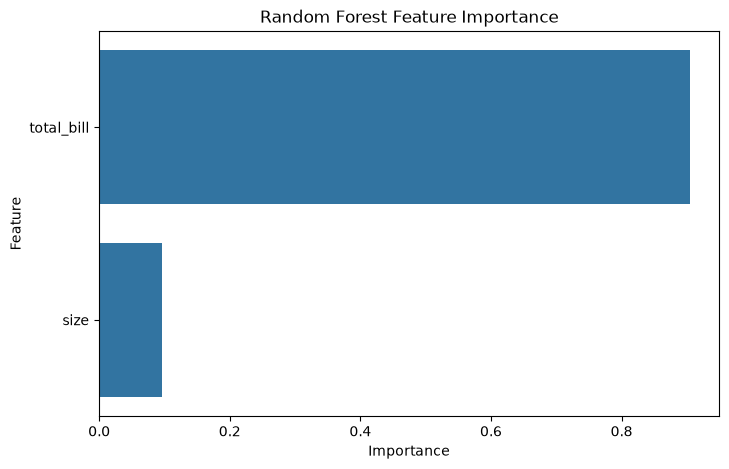

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

## Decision Tree vs Random Forest

### Decision Tree

Uses one tree:

Data
 ↓
Decision Tree
 ↓
Prediction

### Random Forest

Uses many trees:

Data
 ↓
Tree 1 ──┐
Tree 2 ──┤
Tree 3 ──┤
Tree 4 ──┤
  ...    │
Tree N ──┘
         ↓
      Average
         ↓
     Prediction

Random Forest generally provides better stability and reduces the
variance of a single Decision Tree.

In [32]:
new_data = pd.DataFrame({
    "total_bill": [50],
    "size": [3]
})

prediction = model.predict(
    new_data
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 8.622300000000001


## Out-of-Bag (OOB) Evaluation

Random Forest can use Out-of-Bag samples to estimate model performance.

During bootstrap sampling, some training observations are not selected
for a particular tree.

These unused observations are called Out-of-Bag samples.

Setting:

oob_score=True

allows Random Forest to calculate an OOB score.

This can provide an additional estimate of model performance without
using a separate validation set for that particular estimate.

In [33]:
oob_model = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,
    random_state=42
)

oob_model.fit(
    X_train,
    y_train
)

print("OOB R² Score:", oob_model.oob_score_)

OOB R² Score: 0.17394652095178675


## Advantages of Random Forest Regression

- Handles non-linear relationships.
- Usually requires little preprocessing.
- Does not require feature scaling.
- Less prone to overfitting than a single deep decision tree.
- Can capture feature interactions.
- Provides feature importance.
- Works well on many tabular datasets.

## Disadvantages of Random Forest Regression

- More computationally expensive than a single Decision Tree.
- Uses more memory.
- The model is harder to interpret than one Decision Tree.
- Large forests can take longer to train and predict.
- Feature importance can sometimes be misleading when features are
  highly correlated.